# EX6：移除 EX4 漏报相关特征的 BASE 双模型消融实验

目的：检验移除 EX4 低风险 FN waterfall 图中频繁出现的 `V4`、`V10`、`V12`（以及可选的 `Time`）后，是否能减少漏报并提高欺诈金额召回。

本实验与主 notebook §2 的 BASE 评估对齐：仅使用 BASE 特征、LightGBM/XGBoost 双模型、5 折 Purged Walk-Forward、训练折内时间序早停、完整 OOF，以及按时间顺序的 cal 定阈值 / eval 报 F1。三个方案共用该协议，且不重新调参；因此差异只反映特征移除的影响。

In [1]:
# 唯一导入单元：所有标准库和第三方包均在此处导入
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (_candidate / 'input' / 'creditcard.csv').exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError('无法定位 input/creditcard.csv，请在项目目录内运行本 notebook。')

if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from experiments.winner_cv_utils import (
    CV_N_SPLITS, CV_RANDOM_STATE, _oof_cal_mask, bind_cv_data, fit_classifier,
    iter_purged_cv_folds, make_classifier, metrics_at_threshold_honest,
    read_creditcard_csv, split_early_stop_set,
)


## 1. 实验配置

三个方案均以 `V1–V28 + Amount + Time` 为起点。`DROP_V4_V10_V12` 检验 EX4 中反复出现的低风险 FN 特征；`DROP_V4_V10_V12_TIME` 进一步检验时间特征是否加剧该漏报模式。

In [2]:
# EX6 prep：路径、特征方案和评估函数
DATA_PATH_EX6 = PROJECT_ROOT / 'input' / 'creditcard.csv'
OUT_EX6 = PROJECT_ROOT / 'src' / 'output' / 'final_report' / 'EX6_drop_ex4_fn_features'
OUT_EX6.mkdir(parents=True, exist_ok=True)

EX6_MODELS = ('LightGBM', 'XGBoost')
EX6_DROPPED_V = ('V4', 'V10', 'V12')
EX6_VARIANTS = {
    'BASE': (),
    'DROP_V4_V10_V12': EX6_DROPPED_V,
    'DROP_V4_V10_V12_TIME': (*EX6_DROPPED_V, 'Time'),
}


def ex6_base_features(data):
    return [col for col in data.columns if col.startswith('V')] + ['Amount', 'Time']


def ex6_amount_metrics(y_true, oof_proba, amount, threshold):
    """与主 notebook honest F1 相同的 OOF cal/eval 切分上计算金额指标。"""
    y_arr = np.asarray(y_true, dtype=int)
    p_arr = np.asarray(oof_proba, dtype=float)
    amount_arr = np.asarray(amount, dtype=float)
    valid = np.isfinite(p_arr)
    y_valid, p_valid, amount_valid = y_arr[valid], p_arr[valid], amount_arr[valid]
    cal_mask, _ = _oof_cal_mask(y_valid)
    y_eval, p_eval, amount_eval = y_valid[~cal_mask], p_valid[~cal_mask], amount_valid[~cal_mask]
    pred = p_eval >= float(threshold)
    fraud_amount = float(amount_eval[y_eval == 1].sum())
    caught_amount = float(amount_eval[(y_eval == 1) & pred].sum())
    missed_amount = float(amount_eval[(y_eval == 1) & (~pred)].sum())
    tp = int(((y_eval == 1) & pred).sum())
    fn = int(((y_eval == 1) & (~pred)).sum())
    return {
        'TP': tp, 'FN': fn, 'FraudAmount_eval': fraud_amount,
        'CaughtAmount_eval': caught_amount, 'MissedAmount_eval': missed_amount,
        'AmountRecall_eval': caught_amount / fraud_amount if fraud_amount > 0 else np.nan,
    }


def ex6_cross_val_eval(model_name, data, feature_cols):
    """复用主 notebook §2 的训练协议，并输出折级进度。"""
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)
    fold_ap = []
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(len(X), n_splits=CV_N_SPLITS), start=1):
        fold_start = time.perf_counter()
        print(f'  {model_name} | fold {fold}/{CV_N_SPLITS}：训练中…', flush=True)
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(
            X_tr, y_tr, random_state=CV_RANDOM_STATE + fold,
        )
        clf = make_classifier(model_name, y_fit, params=None, random_state=CV_RANDOM_STATE + fold)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba_va = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba_va
        ap = float(average_precision_score(y_va, proba_va))
        fold_ap.append(ap)
        print(f'  {model_name} | fold {fold}/{CV_N_SPLITS}：完成，AUC-PR={ap:.4f}，耗时={time.perf_counter() - fold_start:.1f}s', flush=True)
    honest = metrics_at_threshold_honest(y.to_numpy(), oof)
    return {
        'AUC-PR_mean': float(np.mean(fold_ap)), 'AUC-PR_std': float(np.std(fold_ap, ddof=0)),
        'F1@combo_t*': honest['F1@combo_t*'], 'Precision@best': honest['Precision@best'],
        'Recall@best': honest['Recall@best'], 'FP': honest['FP'], 'best_threshold': honest['best_threshold'],
        'n_eval': honest['n_eval'], 'oof': oof,
    }


def ex6_run_variant(model_name, data, base_features, variant_name, dropped_features):
    feature_cols = [col for col in base_features if col not in dropped_features]
    result = ex6_cross_val_eval(model_name, data, feature_cols)
    amount_result = ex6_amount_metrics(
        data['Class'].to_numpy(), result['oof'], data['Amount'].to_numpy(), result['best_threshold'],
    )
    return {
        '模型': model_name, '特征方案': variant_name,
        '移除特征': '—' if not dropped_features else '、'.join(dropped_features),
        '特征数': len(feature_cols), 'AUC-PR_mean': result['AUC-PR_mean'],
        'AUC-PR_std': result['AUC-PR_std'], 'F1@combo_t*': result['F1@combo_t*'],
        'Precision@best': result['Precision@best'], 'Recall@best': result['Recall@best'],
        'FP': result['FP'], '阈值@cal': result['best_threshold'],
        'n_eval': result['n_eval'], **amount_result,
    }, pd.DataFrame({'Class': data['Class'], 'Amount': data['Amount'], 'OOF概率': result['oof']})


def ex6_add_base_deltas(summary):
    out = summary.copy()
    for model_name, idx in out.groupby('模型').groups.items():
        base = out.loc[idx][out.loc[idx, '特征方案'] == 'BASE'].iloc[0]
        out.loc[idx, 'ΔFN_vs_BASE'] = out.loc[idx, 'FN'] - int(base['FN'])
        out.loc[idx, 'ΔAmountRecall_vs_BASE'] = out.loc[idx, 'AmountRecall_eval'] - float(base['AmountRecall_eval'])
        out.loc[idx, 'ΔMissedAmount_vs_BASE'] = out.loc[idx, 'MissedAmount_eval'] - float(base['MissedAmount_eval'])
        out.loc[idx, 'ΔF1_vs_BASE'] = out.loc[idx, 'F1@combo_t*'] - float(base['F1@combo_t*'])
    return out


def ex6_plot_amount_tradeoff(summary, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for model_name, part in summary.groupby('模型', sort=False):
        axes[0].plot(part['特征方案'], part['AmountRecall_eval'], marker='o', label=model_name)
        axes[1].plot(part['特征方案'], part['FN'], marker='o', label=model_name)
    axes[0].set_title('欺诈金额召回率（eval）')
    axes[0].set_ylabel('Amount Recall')
    axes[1].set_title('漏报笔数（eval）')
    axes[1].set_ylabel('FN')
    for ax in axes:
        ax.tick_params(axis='x', rotation=20)
        ax.grid(axis='y', alpha=0.25)
        ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    return fig


## 2. 训练、OOF 验收与金额损失比较

同一模型内，以 `BASE` 为参照。`ΔFN_vs_BASE < 0` 表示漏报减少；`ΔAmountRecall_vs_BASE > 0` 表示追回的欺诈金额比例上升；`ΔMissedAmount_vs_BASE < 0` 表示漏掉的欺诈金额减少。只有这些方向与 F1、AUC-PR 的变化一起看，才能判断移除特征是否得不偿失。

运行：LightGBM | BASE
  LightGBM | fold 1/5：训练中…
  LightGBM | fold 1/5：完成，AUC-PR=0.7961，耗时=1.1s
  LightGBM | fold 2/5：训练中…
  LightGBM | fold 2/5：完成，AUC-PR=0.6911，耗时=1.4s
  LightGBM | fold 3/5：训练中…
  LightGBM | fold 3/5：完成，AUC-PR=0.8164，耗时=1.3s
  LightGBM | fold 4/5：训练中…
  LightGBM | fold 4/5：完成，AUC-PR=0.8052，耗时=2.5s
  LightGBM | fold 5/5：训练中…
  LightGBM | fold 5/5：完成，AUC-PR=0.7475，耗时=1.6s
运行：LightGBM | DROP_V4_V10_V12
  LightGBM | fold 1/5：训练中…
  LightGBM | fold 1/5：完成，AUC-PR=0.7659，耗时=1.2s
  LightGBM | fold 2/5：训练中…
  LightGBM | fold 2/5：完成，AUC-PR=0.7056，耗时=1.5s
  LightGBM | fold 3/5：训练中…
  LightGBM | fold 3/5：完成，AUC-PR=0.7739，耗时=1.3s
  LightGBM | fold 4/5：训练中…
  LightGBM | fold 4/5：完成，AUC-PR=0.7730，耗时=2.6s
  LightGBM | fold 5/5：训练中…
  LightGBM | fold 5/5：完成，AUC-PR=0.7420，耗时=1.5s
运行：LightGBM | DROP_V4_V10_V12_TIME
  LightGBM | fold 1/5：训练中…
  LightGBM | fold 1/5：完成，AUC-PR=0.7758，耗时=1.2s
  LightGBM | fold 2/5：训练中…
  LightGBM | fold 2/5：完成，AUC-PR=0.7097，耗时=1.4s
  LightGBM | fold 3/5：训练中…
 

/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_53432/835392575.py:111: UserWarning: Glyph 27450 (\N{CJK UNIFIED IDEOGRAPH-6B3A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_53432/835392575.py:111: UserWarning: Glyph 35784 (\N{CJK UNIFIED IDEOGRAPH-8BC8}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_53432/835392575.py:111: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_53432/835392575.py:111: UserWarning: Glyph 39069 (\N{CJK UNIFIED IDEOGRAPH-989D}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/k9/rjyhrcsd5kb13mj44nc5x34r0000gn/T/ipykernel_53432/835392575.py:111: UserWarning: Glyph 21484 (\N{CJK UNIFIED IDEOGRAPH-53EC}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/k9/rjyh

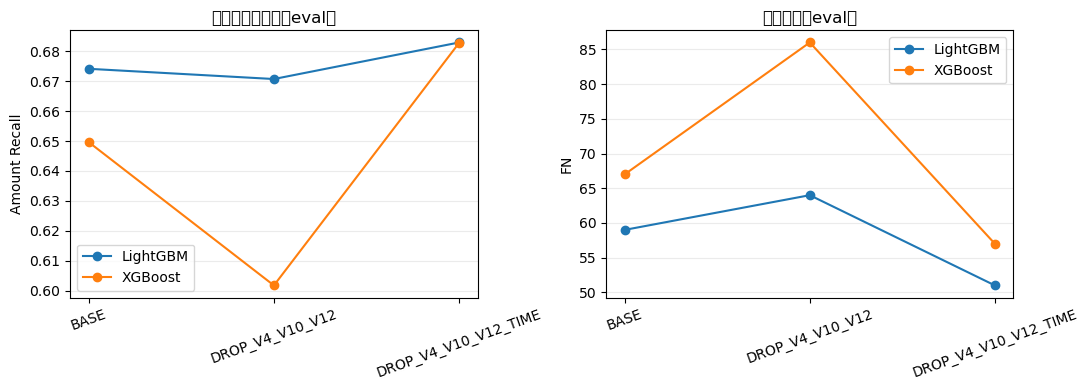

,模型,特征方案,移除特征,特征数,AUC-PR_mean,F1@combo_t*,Recall@best,FP,FN,AmountRecall_eval,MissedAmount_eval,ΔFN_vs_BASE,ΔAmountRecall_vs_BASE,ΔMissedAmount_vs_BASE,ΔF1_vs_BASE
0,LightGBM,BASE,—,30,0.771266,0.754221,0.773077,72,59,0.674198,10858.07,0.0,0.000000,0.00,0.000000
1,LightGBM,DROP_V4_V10_V12,V4、V10、V12,27,0.752060,0.690141,0.753846,112,64,0.670778,10972.07,5.0,-0.003421,114.00,-0.064081
2,LightGBM,DROP_V4_V10_V12_TIME,V4、V10、V12、Time,26,0.759324,0.535897,0.803846,311,51,0.683007,10564.48,-8.0,0.008809,-293.59,-0.218324
3,XGBoost,BASE,—,30,0.769454,0.750973,0.742308,61,67,0.649636,11676.65,0.0,0.000000,0.00,0.000000
4,XGBoost,DROP_V4_V10_V12,V4、V10、V12,27,0.753785,0.746781,0.669231,32,86,0.601700,13274.22,19.0,-0.047936,1597.57,-0.004192
5,XGBoost,DROP_V4_V10_V12_TIME,V4、V10、V12、Time,26,0.756094,0.690476,0.780769,125,57,0.682828,10570.47,-10.0,0.033191,-1106.18,-0.060497


已保存 EX6 输出 → /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/EX6_drop_ex4_fn_features


In [3]:
# EX6 exec：运行三组 BASE 特征消融，并保存可比较的 OOF 验收结果
df_ex6 = bind_cv_data(read_creditcard_csv(DATA_PATH_EX6))
base_features_ex6 = ex6_base_features(df_ex6)
rows_ex6, oof_exports_ex6 = [], {}

for model_name_ex6 in EX6_MODELS:
    for variant_name_ex6, dropped_features_ex6 in EX6_VARIANTS.items():
        print(f'运行：{model_name_ex6} | {variant_name_ex6}')
        row_ex6, oof_export_ex6 = ex6_run_variant(
            model_name_ex6, df_ex6, base_features_ex6, variant_name_ex6, dropped_features_ex6,
        )
        rows_ex6.append(row_ex6)
        oof_exports_ex6[f'{model_name_ex6}_{variant_name_ex6}'] = oof_export_ex6

summary_ex6 = ex6_add_base_deltas(pd.DataFrame(rows_ex6))
summary_ex6 = summary_ex6.sort_values(['模型', '特征方案']).reset_index(drop=True)
summary_ex6.to_csv(OUT_EX6 / 'ex6_drop_feature_summary.csv', index=False, encoding='utf-8-sig')
for export_name_ex6, export_df_ex6 in oof_exports_ex6.items():
    export_df_ex6.to_csv(OUT_EX6 / f'{export_name_ex6}_oof.csv', index=False, encoding='utf-8-sig')

fig_ex6 = ex6_plot_amount_tradeoff(summary_ex6, OUT_EX6 / 'ex6_amount_recall_and_fn.png')
plt.show()

display_cols_ex6 = [
    '模型', '特征方案', '移除特征', '特征数', 'AUC-PR_mean', 'F1@combo_t*',
    'Recall@best', 'FP', 'FN', 'AmountRecall_eval', 'MissedAmount_eval',
    'ΔFN_vs_BASE', 'ΔAmountRecall_vs_BASE', 'ΔMissedAmount_vs_BASE', 'ΔF1_vs_BASE',
]
display(summary_ex6[display_cols_ex6].round(6))
print('已保存 EX6 输出 →', OUT_EX6)
